In [440]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

In [ ]:
mean_waiting = 10 #среднее время ожидания
std_waiting = 3 #стандартное отклонение

# Преобразуем mean и std в mu и sigma для логнормального
sigma = np.sqrt(np.log(1 + (std_waiting/mean_waiting)**2))
mu = np.log(mean_waiting) - (sigma**2) / 2

print(f"Параметры логнормального распределения:")
print(f"mu = {mu:.4f}, sigma = {sigma:.4f}")
print(f"Проверка: M[T] = {np.exp(mu + (sigma**2)/2):.2f}, σ[T] = {np.sqrt((np.exp(sigma**2)-1)*np.exp(2*mu + sigma**2)):.2f}")

Параметры логнормального распределения:
mu = 2.2595, sigma = 0.2936
Проверка: M[T] = 10.00, σ[T] = 3.00


Теперь сгенерируйте n = 10 значений случайной величины Т и на основе этих данных определите частоту (статистическую вероятность) W(A) появления события А, равного ожиданию 41 автобуса на остановке мене 5 минут (0 — событие не произошло, 1 — произошло).

В scipy.stats.lognorm параметр s — это sigma , а scale — это е^mu

In [442]:
n = 10
T_values = stats.lognorm.rvs(s=sigma, scale=np.exp(mu), size=n)
A_values = (T_values < 5).astype(int)
W_A = np.mean(A_values)
print(f"Сгенерированные значения случайной величины Т: {T_values}")
print(f"Сгенерированные значения события А: {A_values}")
print(f"Частота (статистическая вероятность) W(A) = {W_A:.4f}")

Сгенерированные значения случайной величины Т: [10.33913932  7.71410849  7.6690301  12.61978036 10.71634227  7.9622056
 10.25423698 12.8144603  11.27351984  7.02777207]
Сгенерированные значения события А: [0 0 0 0 0 0 0 0 0 0]
Частота (статистическая вероятность) W(A) = 0.0000


In [443]:
p_true = stats.lognorm.cdf(5, s=sigma, scale=np.exp(mu))
print(f"Истинное значение вероятности p = {p_true:.4f}")

Истинное значение вероятности p = 0.0134


In [444]:
epsilon = 0.1

sigma_p = np.sqrt(p_true * (1 - p_true) / n)
K_estimated = 2 * stats.norm.cdf(epsilon / sigma_p) - 1

print(f"Оценка вероятности K для ε={epsilon}, n = {n} равна {K_estimated:.4f}")

Оценка вероятности K для ε=0.1, n = 10 равна 0.9940


- Распределение биноминальное потому что считаем число «успехов» в n независимых испытаниях Бернулли: для каждого наблюдения событие A=1{T<5} происходит с одной и той же вероятностью p и независимо от других.
- Не близки

In [445]:
print(f"Отклонение {epsilon:.4f}")
print(f"Вероятность {K_estimated:.4f}")

Отклонение 0.1000
Вероятность 0.9940


Для этого будем N = 100 раз генерировать по n = 10 времен T и вычислять по ним соответствующие частоты. Должно получиться 100 значений частот W(a). Отобразите результат на графике (ось — номер испытания, — частота).

In [446]:
N = 100

W_A_values = []
for _ in range(N):
    T_values = stats.lognorm.rvs(s=sigma, scale=np.exp(mu), size=n)
    A_values = (T_values < 5).astype(int)
    W_A = np.mean(A_values)
    W_A_values.append(W_A)

W_A_values = np.array(W_A_values)

in_range = np.sum((W_A_values >= p_true - epsilon) & (W_A_values <= p_true + epsilon))
K_actual = in_range / N

print(f"Реальная доля попаданий в диапазон p ± ε: {K_actual:.4f} ({in_range}/100)")
print(f"Теоретическая вероятность попадания в диапазон p ± ε: {K_estimated:.4f}")
print(f"Среднее значение частоты {np.mean(W_A_values):.4f}")
print(f"Среднее отклонение {np.std(W_A_values):.4f}")

Реальная доля попаданий в диапазон p ± ε: 0.9900 (99/100)
Теоретическая вероятность попадания в диапазон p ± ε: 0.9940
Среднее значение частоты 0.0110
Среднее отклонение 0.0343


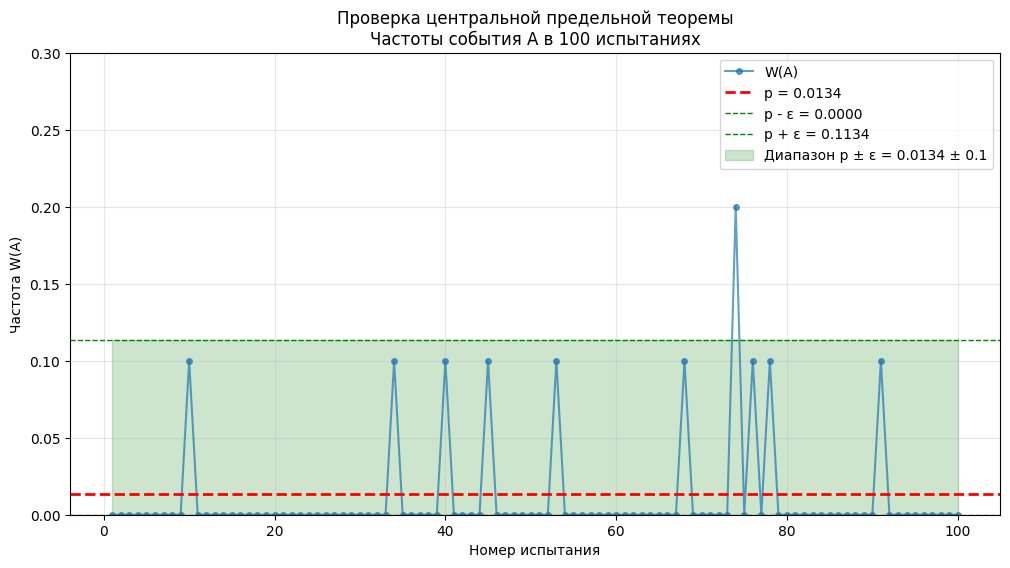

In [447]:
plt.figure(figsize=(12, 6))
lower_bound = max(0, p_true - epsilon)
upper_bound = p_true + epsilon

plt.plot(range(1, N + 1), W_A_values, 'o-', alpha=0.7, label='W(A)', markersize=4)
plt.axhline(y=p_true, color='r', linestyle='--', linewidth=2, label=f'p = {p_true:.4f}')
plt.axhline(y=lower_bound, color='g', linestyle='--', linewidth=1, label=f'p - ε = {lower_bound:.4f}')
plt.axhline(y=upper_bound, color='g', linestyle='--', linewidth=1, label=f'p + ε = {upper_bound:.4f}')
plt.fill_between(range(1, N + 1), lower_bound, upper_bound, color='g', alpha=0.2, label=f'Диапазон p ± ε = {p_true:.4f} ± {epsilon}')

plt.ylim(0, max(W_A_values) + epsilon)

plt.xlabel('Номер испытания')
plt.ylabel('Частота W(A)')
plt.title('Проверка центральной предельной теоремы\nЧастоты события A в 100 испытаниях')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [448]:
print(f"Истинная вероятность: {p_true:.4f}")
print(f"ε = {epsilon:.3f}") 
print(f"Диапазон: [{lower_bound:.3f}, {upper_bound:.3f}]")
print(f"Минимальная частота: {np.min(W_A_values):.3f}")
print(f"Максимальная частота: {np.max(W_A_values):.3f}")

# Сколько значений попало в диапазон [p-ε, p+ε]
count_in_range = np.sum((W_A_values >= lower_bound) & (W_A_values <= upper_bound))
print(f"Попало в диапазон: {count_in_range} из {W_A_values.size} ({count_in_range / W_A_values.size:.2%})")

Истинная вероятность: 0.0134
ε = 0.100
Диапазон: [0.000, 0.113]
Минимальная частота: 0.000
Максимальная частота: 0.200
Попало в диапазон: 99 из 100 (99.00%)


3. Теперь установите какое количество испытаний надо провести, чтобы можно было
утверждать, что частота отклоняется от истинной вероятности менее чем на 0.1 с
вероятностью 0.9. Проверьте полученный результат (как в пункте 2).

ppf - это обратная функция к cdf:

cdf(x) = "Какова вероятность, что значение ≤ x?"

ppf(p) = "Какое значение x дает вероятность p?"

In [449]:
epsilon_target = 0.1
K_target = 0.9

# Решаем уравнение: 2Φ(ε√(n/(p(1-p)))) - 1 = K
z_target = stats.norm.ppf((1 + K_target) / 2)
n_required = (z_target**2 * p_true * (1 - p_true)) / epsilon_target**2
n_required = int(np.ceil(n_required))
print(f"Для ε={epsilon_target} и K={K_target} требуется:")
print(f"n ≥ {n_required} испытаний")

Для ε=0.1 и K=0.9 требуется:
n ≥ 4 испытаний


In [450]:
W_A_values_check = []
for i in range(N):
    T_values = stats.lognorm.rvs(s=sigma, scale=np.exp(mu), size=n_required)
    A_values = (T_values < 5).astype(int)
    W_A = np.mean(A_values)
    W_A_values_check.append(W_A)

W_A_values_check = np.array(W_A_values_check)
in_range_check = np.sum((W_A_values_check >= p_true - epsilon_target) & (W_A_values_check <= p_true + epsilon_target))

K_actual_check = in_range_check / N

print(f"Реальная вероятность попадания в диапазон p ± ε: {K_actual_check:.4f} ({in_range_check}/100)")
print(f"Теоретическая вероятность попадания в диапазон p ± ε: {K_target:.4f}")
print(f"Среднее значение частоты {np.mean(W_A_values_check):.4f}")
print(f"Среднее отклонение {np.std(W_A_values_check):.4f}")

Реальная вероятность попадания в диапазон p ± ε: 0.9300 (93/100)
Теоретическая вероятность попадания в диапазон p ± ε: 0.9000
Среднее значение частоты 0.0175
Среднее отклонение 0.0638


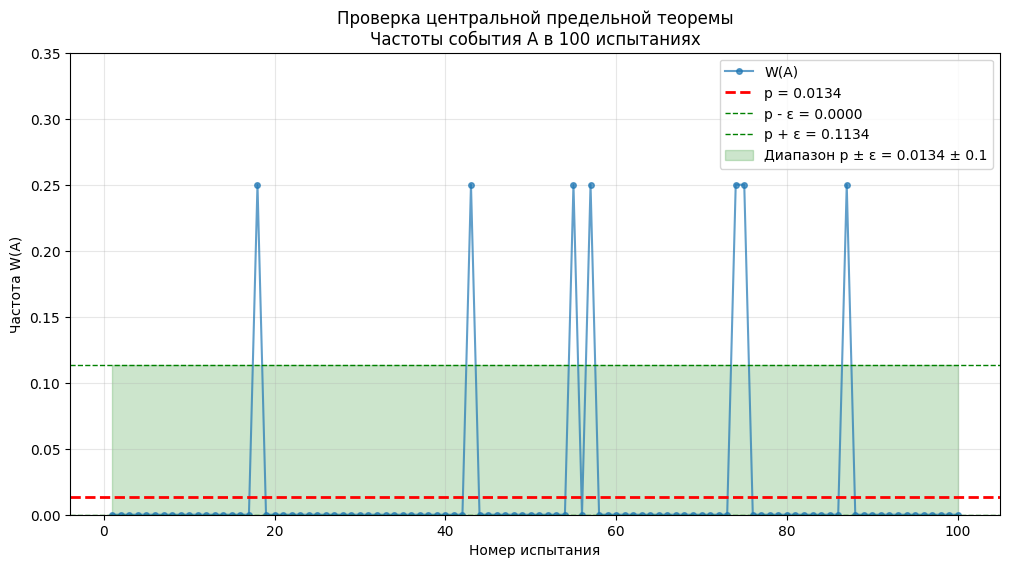

In [451]:
plt.figure(figsize=(12, 6))
lower_bound_check = max(0, p_true - epsilon_target)
upper_bound_check = p_true + epsilon_target

plt.plot(range(1, N + 1), W_A_values_check, 'o-', alpha=0.7, label='W(A)', markersize=4)
plt.axhline(y=p_true, color='r', linestyle='--', linewidth=2, label=f'p = {p_true:.4f}')
plt.axhline(y=lower_bound_check, color='g', linestyle='--', linewidth=1, label=f'p - ε = {lower_bound_check:.4f}')
plt.axhline(y=upper_bound_check, color='g', linestyle='--', linewidth=1, label=f'p + ε = {upper_bound_check:.4f}')
plt.fill_between(range(1, N + 1), lower_bound_check, upper_bound_check, color='g', alpha=0.2, label=f'Диапазон p ± ε = {p_true:.4f} ± {epsilon_target}')

plt.ylim(0, max(W_A_values_check) + epsilon_target)

plt.xlabel('Номер испытания')
plt.ylabel('Частота W(A)')
plt.title('Проверка центральной предельной теоремы\nЧастоты события A в 100 испытаниях')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [452]:
print(f"Истинная вероятность: {p_true:.4f}")
print(f"ε = {epsilon_target:.3f}")
print(f"Диапазон: [{lower_bound_check:.3f}, {upper_bound_check:.3f}]")
print(f"Минимальная частота: {np.min(W_A_values_check):.3f}")
print(f"Максимальная частота: {np.max(W_A_values_check):.3f}")

# Сколько значений попало в диапазон [p-ε, p+ε]
count_in_range_check = np.sum((W_A_values_check >= lower_bound_check) & (W_A_values_check <= upper_bound_check))
print(f"Попало в диапазон: {count_in_range_check} из {W_A_values_check.size} ({count_in_range_check / W_A_values_check.size:.2%})")

Истинная вероятность: 0.0134
ε = 0.100
Диапазон: [0.000, 0.113]
Минимальная частота: 0.000
Максимальная частота: 0.250
Попало в диапазон: 93 из 100 (93.00%)


4. Используя формулу (1) ответьте на вопросы:

Как изменится вероятность K, если уменьшить ε?

Как изменится вероятность K, если уменьшить n?

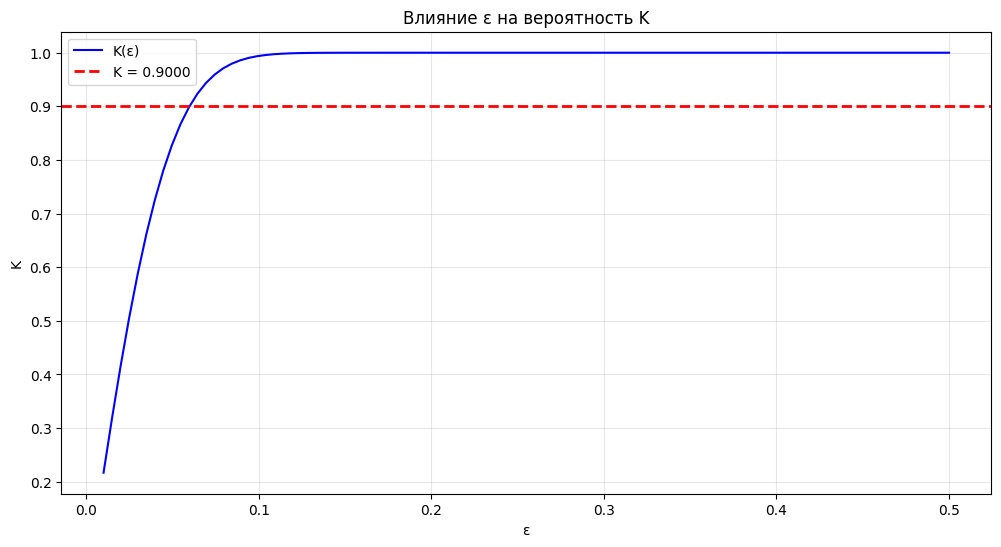

In [453]:
def calculate_k_probability(epsilon, n, p):
    return 2 * stats.norm.cdf(epsilon * np.sqrt(n / (p * (1 - p)))) - 1

#анализ влияния уменьшения ε
epsilon_values = np.linspace(0.01, 0.5, 100)
K_values_epsilon = [calculate_k_probability(eps, n, p_true) for eps in epsilon_values]

plt.figure(figsize=(12, 6))
plt.plot(epsilon_values, K_values_epsilon, label='K(ε)', color='blue')
plt.axhline(y=K_target, color='r', linestyle='--', linewidth=2, label=f'K = {K_target:.4f}')
plt.xlabel('ε')
plt.ylabel('K')
plt.title('Влияние ε на вероятность K')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

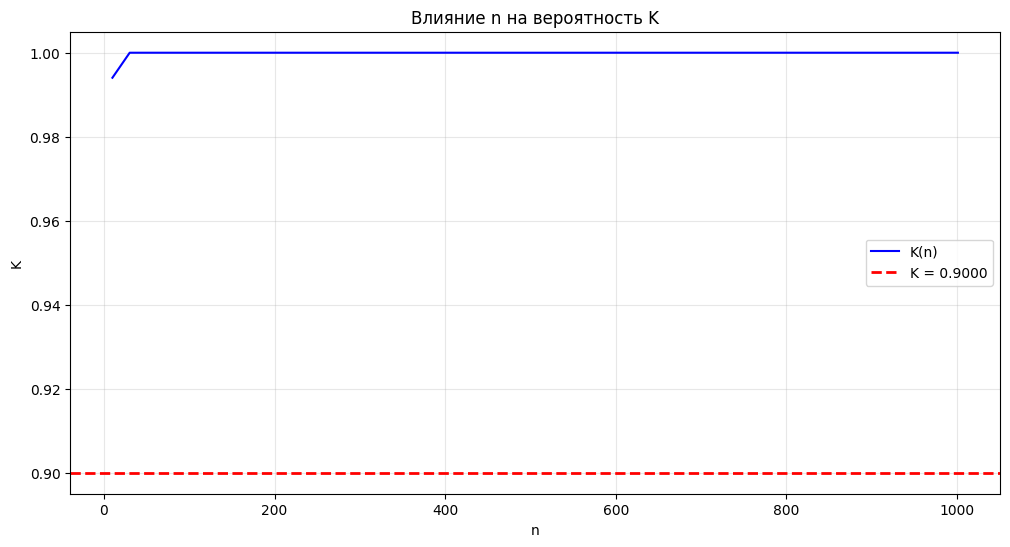

In [454]:
n_values = np.linspace(10, 1001)
K_values_n = [calculate_k_probability(epsilon_target, n, p_true) for n in n_values]

plt.figure(figsize=(12, 6))
plt.plot(n_values, K_values_n, label='K(n)', color='blue')
plt.axhline(y=K_target, color='r', linestyle='--', linewidth=2, label=f'K = {K_target:.4f}')
plt.xlabel('n')
plt.ylabel('K')
plt.title('Влияние n на вероятность K')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [455]:
print("Выводы:")
print("1. При уменьшении ε вероятность K уменьшается")
print("2. При уменьшении n вероятность K также уменьшается")

Выводы:
1. При уменьшении ε вероятность K уменьшается
2. При уменьшении n вероятность K также уменьшается
